<a href="https://colab.research.google.com/github/lieseld07/mlproject/blob/main/riskscore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Upload and read data
from google.colab import files
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

uploaded = files.upload() # Uncommented to allow file upload
df = pd.read_csv("Final_data.csv")

# Convert Temperature from Kelvin to Celsius
if "Temp" in df.columns:
    df["Temp_C"] = df["Temp"] - 273.15

# Select features used for risk score
features = ["Cases", "preci", "Temp_C"]

# Convert to numeric and handle missing values
for col in features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[features] = df[features].fillna(df[features].mean())

# ---------------- NORMALIZATION ----------------
scaler = MinMaxScaler()
df_norm = df.copy()
df_norm[features] = scaler.fit_transform(df[features])

# ---------------- WEIGHTS ----------------
w_cases = 0.4
w_preci = 0.3
w_temp  = 0.3

# ---------------- RISK SCORE ----------------
df_norm["Risk_Score"] = (
    w_cases * df_norm["Cases"] +
    w_preci * df_norm["preci"] +
    w_temp  * df_norm["Temp_C"]
)
print(df_norm["Risk_Score"].head())

# ---------------- RISK CATEGORIZATION ----------------
df_norm["Risk_Level"] = pd.qcut(
    df_norm["Risk_Score"],
    q=3,
    labels=["Low Risk", "Moderate Risk", "High Risk"]
)

# Display results
print(df_norm[["Risk_Score", "Risk_Level"]].head())
print(df_norm["Risk_Level"].value_counts())
print(df_norm[df_norm["Risk_Level"] == "High Risk"].head())

Saving Final_data.csv to Final_data.csv
0    0.142747
1    0.178066
2    0.186865
3    0.177186
4    0.193387
Name: Risk_Score, dtype: float64
   Risk_Score Risk_Level
0    0.142747   Low Risk
1    0.178066   Low Risk
2    0.186865   Low Risk
3    0.177186   Low Risk
4    0.193387   Low Risk
Risk_Level
Low Risk         2995
Moderate Risk    2995
High Risk        2995
Name: count, dtype: int64
    Unnamed: 0 week_of_outbreak        state_ut      district  \
50          50        14th week       Telangana     Hyderabad   
54          54        15th week      Tamil Nadu  Kallakurichi   
74          74        18th week         Gujarat   Sabarkantha   
76          76        18th week  Madhya Pradesh      Mandsaur   
86          86        19th week       Karnataka    Kalaburagi   

                     Disease     Cases  Deaths  day  mon  year   Latitude  \
50  Acute Diarrhoeal Disease  0.001835     NaN    8    4  2022  17.360589   
54  Acute Diarrhoeal Disease  0.000254     NaN   17    4  2

In [4]:
risk_score_quantiles = df_norm["Risk_Score"].quantile([1/3, 2/3])
print("Quantile boundaries for Risk_Score:")
print(risk_score_quantiles)

# Based on the output, we can deduce:
# - Scores below the first quantile are 'Low Risk'
# - Scores between the first and second quantile are 'Moderate Risk'
# - Scores above the second quantile are 'High Risk'

Quantile boundaries for Risk_Score:
0.333333    0.206977
0.666667    0.232765
Name: Risk_Score, dtype: float64


Saving Final_data.csv to Final_data (2).csv


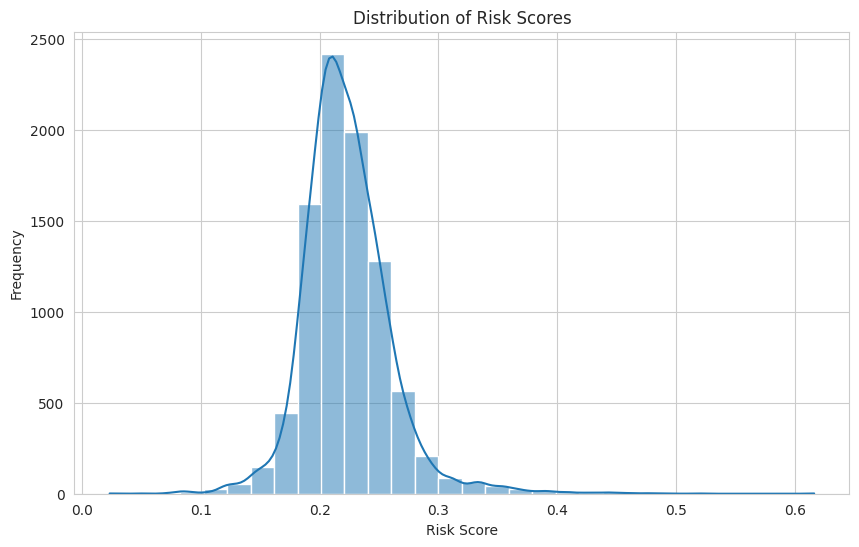

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
uploaded = files.upload()
df = pd.read_csv("Final_data.csv")

# Set a style for the plots for better aesthetics
sns.set_style("whitegrid")

# 1. Visualize the distribution of 'Risk_Score'
plt.figure(figsize=(10, 6))
sns.histplot(df_norm["Risk_Score"], kde=True, bins=30)
plt.title('Distribution of Risk Scores')
plt.xlabel('Risk Score')
plt.ylabel('Frequency')
plt.show()

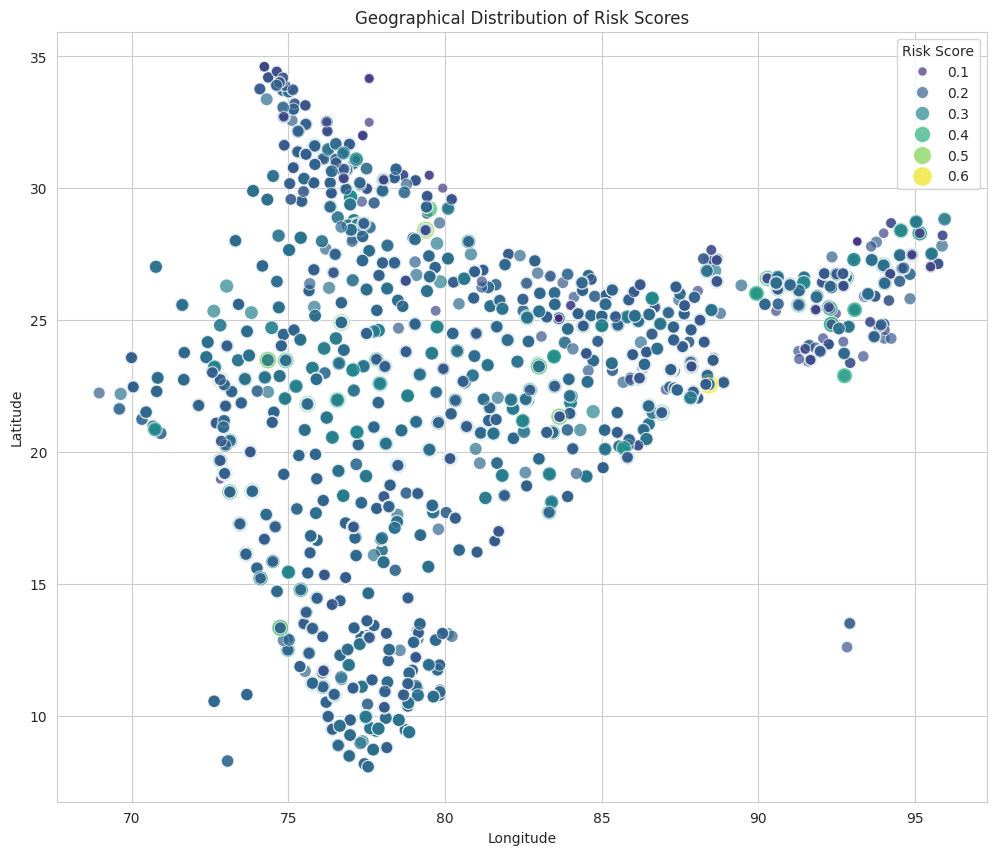

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='Longitude',
    y='Latitude',
    hue='Risk_Score',
    data=df_norm,
    palette='viridis', # Choose a suitable colormap
    size='Risk_Score', # Optional: make point size proportional to risk score
    sizes=(20, 200),  # Range of sizes for the points
    alpha=0.7
)
plt.title('Geographical Distribution of Risk Scores')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Risk Score')
plt.show()

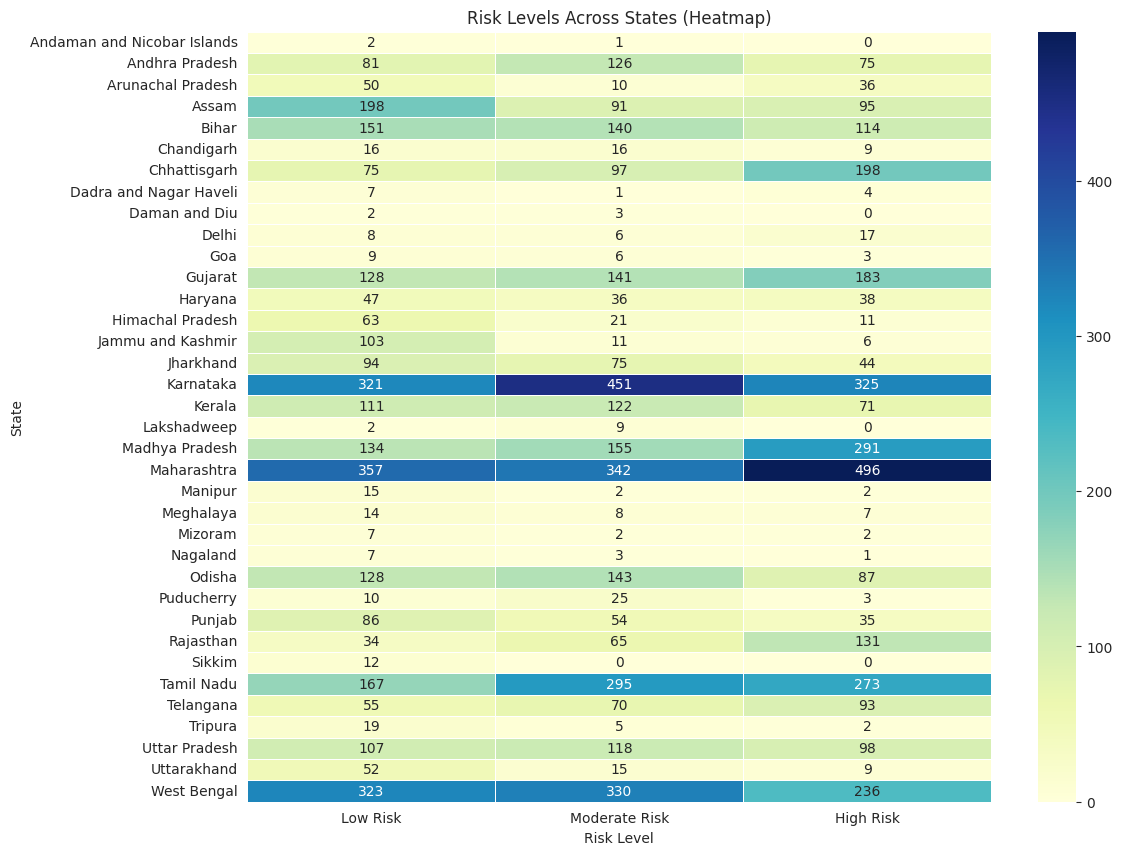

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by state and risk level and count occurrences
risk_by_state = df_norm.groupby(['state_ut', 'Risk_Level'], observed=False).size().unstack(fill_value=0)

# Ensure the order of columns (risk levels) for consistent visualization
risk_by_state = risk_by_state[["Low Risk", "Moderate Risk", "High Risk"]]

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(risk_by_state, annot=True, fmt="d", cmap="YlGnBu", linewidths=.5)
plt.title('Risk Levels Across States (Heatmap)')
plt.xlabel('Risk Level')
plt.ylabel('State')
plt.show()

In [ ]:
# Ensure 'year', 'mon', 'day' are numeric (though they likely already are)
df_norm['year'] = pd.to_numeric(df_norm['year'], errors='coerce')
df_norm['mon'] = pd.to_numeric(df_norm['mon'], errors='coerce')
df_norm['day'] = pd.to_numeric(df_norm['day'], errors='coerce')

# Create a 'Date' column from 'year', 'mon', 'day'
# Handle potential errors during date creation by explicitly mapping column names
df_norm['Date'] = pd.to_datetime({
    'year': df_norm['year'],
    'month': df_norm['mon'], # Map 'mon' column to 'month' component
    'day': df_norm['day']
}, errors='coerce')

# Drop rows where Date could not be parsed
df_norm.dropna(subset=['Date'], inplace=True)

# Sort by date for proper time series analysis
df_norm.sort_values(by='Date', inplace=True)

# Group by week and calculate the mean Risk_Score
# You might choose a different frequency like 'M' for month or 'D' for day
weekly_risk = df_norm.set_index('Date').resample('W')['Risk_Score'].mean().reset_index()

print("Weekly Risk Score trends:")
display(weekly_risk.head())

Weekly Risk Score trends:


,Date,Risk_Score
0,2009-05-10,0.247129
1,2009-05-17,NaN
2,2009-05-24,NaN
3,2009-05-31,0.616440
4,2009-06-07,0.196738


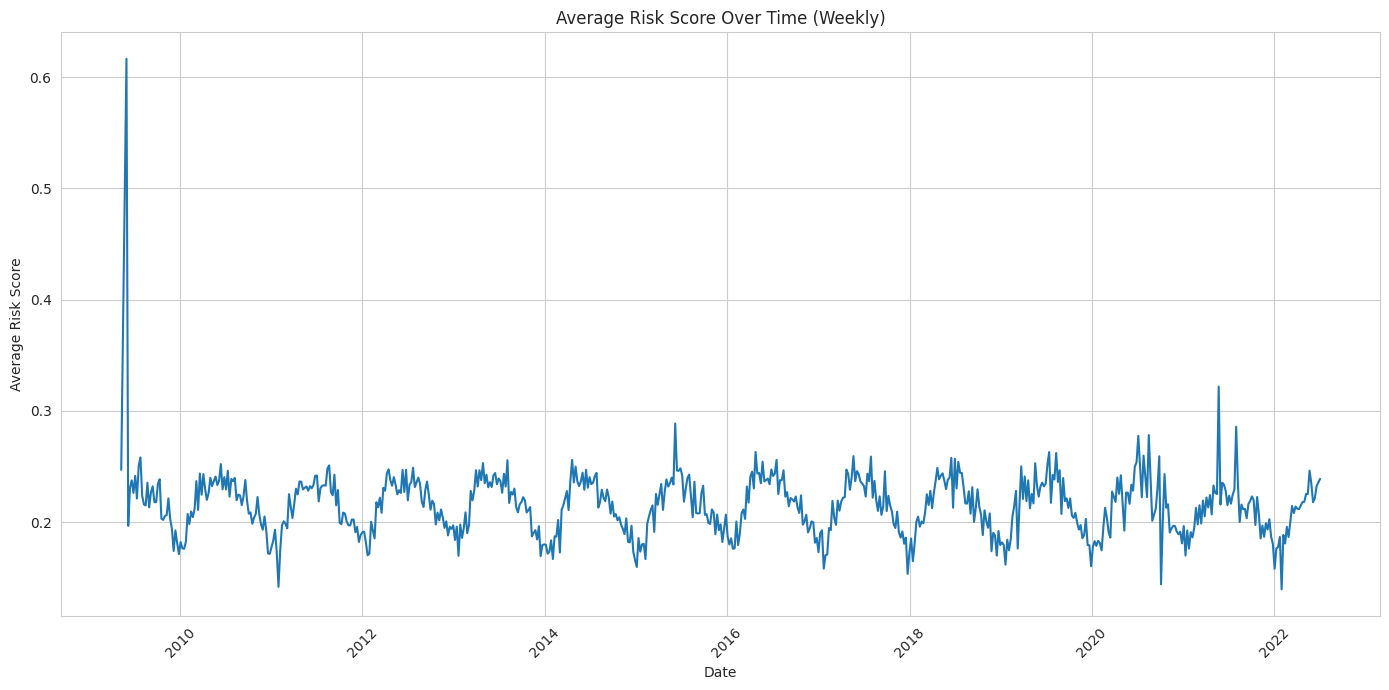

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Risk_Score', data=weekly_risk)
plt.title('Average Risk Score Over Time (Weekly)')
plt.xlabel('Date')
plt.ylabel('Average Risk Score')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This plot shows the average risk score calculated on a weekly basis over the available time period. You can observe trends, seasonality, or sudden changes in risk levels. If you'd like to aggregate by a different time unit (e.g., monthly, daily), let me know!

### Distribution of Risk Levels

/tmp/ipykernel_1045/4049883536.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk_Level', data=df_norm, order=["Low Risk", "Moderate Risk", "High Risk"], palette='viridis')


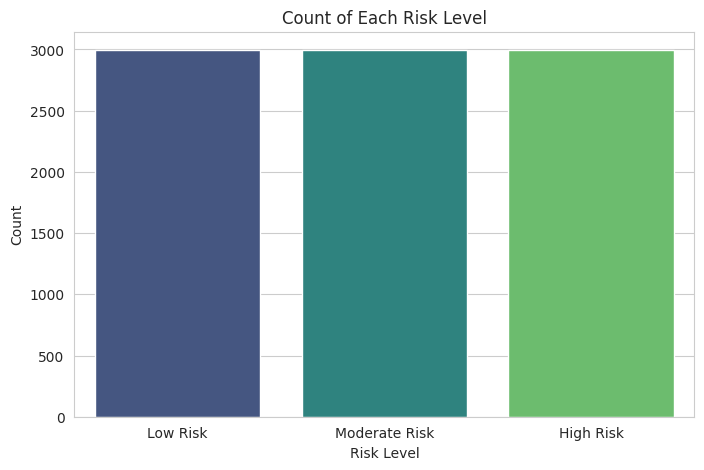

In [ ]:
# 3. Visualize the counts of each 'Risk_Level'
plt.figure(figsize=(8, 5))
sns.countplot(x='Risk_Level', data=df_norm, order=["Low Risk", "Moderate Risk", "High Risk"], palette='viridis')
plt.title('Count of Each Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.show()


### Machine Learning Model for Risk Level Prediction

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define features (X) and target (y)
# The features used for risk score calculation are a good starting point
X = df_norm[features]
y = df_norm['Risk_Level']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (6289, 3)
Shape of X_test: (2696, 3)
Shape of y_train: (6289,)
Shape of y_test: (2696,)


### Train a Random Forest Classifier

In [ ]:
# Initialize and train a RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model training complete.")


Model training complete.


### Evaluate Model Performance

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9766320474777448

Classification Report:
               precision    recall  f1-score   support

    High Risk       0.98      0.98      0.98       898
     Low Risk       0.98      0.99      0.98       899
Moderate Risk       0.97      0.96      0.97       899

     accuracy                           0.98      2696
    macro avg       0.98      0.98      0.98      2696
 weighted avg       0.98      0.98      0.98      2696



### Machine Learning Model for Risk Level Prediction

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define features (X) and target (y)
# The features used for risk score calculation are a good starting point
X = df_norm[features]
y = df_norm['Risk_Level']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (6289, 3)
Shape of X_test: (2696, 3)
Shape of y_train: (6289,)
Shape of y_test: (2696,)


### Train a Random Forest Classifier

In [ ]:
# Initialize and train a RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


### Evaluate Model Performance

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9766320474777448

Classification Report:
               precision    recall  f1-score   support

    High Risk       0.98      0.98      0.98       898
     Low Risk       0.98      0.99      0.98       899
Moderate Risk       0.97      0.96      0.97       899

     accuracy                           0.98      2696
    macro avg       0.98      0.98      0.98      2696
 weighted avg       0.98      0.98      0.98      2696

